<a href="https://colab.research.google.com/github/MMujtabaX/Markov-Models-Text-Classification/blob/main/Markov_Models_and_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Markov Models and Text Classification Fundamentals

In this notebook we cover:
1. **Markov chains**: states, transition matrices, simulation and the stationary distribution
2. **Bigram language models**: a Markov chain over words, used to generate text
3. **Evaluating language models**: the zero-probability problem, **Laplace (add-k) smoothing** and **perplexity**
4. **Text classification with Naive Bayes**: topic classification on 20 Newsgroups
5. **Sentiment classification**: Count vs TF-IDF features and **Chi-squared feature selection** on 50,000 IMDB reviews

In [1]:
import random
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

for pkg in ['punkt', 'punkt_tab', 'gutenberg']:
    nltk.download(pkg, quiet=True)

random.seed(42)
np.random.seed(42)

---
## 1. Basics of Markov Models

A **Markov model** predicts the next state using **only the current state**: the future is independent of the past, given the present. This is the **Markov property**:

$$P(X_{t+1} \mid X_t, X_{t-1}, \dots, X_1) = P(X_{t+1} \mid X_t)$$

The simplest form is a **Markov chain**, which moves between a finite set of states according to **transition probabilities**.

### Example: a two-state weather model

| From \ To | Rainy | Sunny |
|-----------|-------|-------|
| **Rainy** | 0.7 | 0.3 |
| **Sunny** | 0.4 | 0.6 |

If today is rainy, tomorrow is rainy with probability 0.7 and sunny with probability 0.3. Each row sums to 1.

In [2]:
states = ['Rainy', 'Sunny']
P = np.array([[0.7, 0.3],    # from Rainy
              [0.4, 0.6]])   # from Sunny

def simulate_chain(start, n_steps, P, states):
    """Generate a sequence of states from a Markov chain."""
    idx = states.index(start)
    sequence = [start]
    for _ in range(n_steps):
        idx = np.random.choice(len(states), p=P[idx])
        sequence.append(states[idx])
    return sequence

print("10-day forecast starting from Rainy:")
print(" -> ".join(simulate_chain('Rainy', 10, P, states)))

10-day forecast starting from Rainy:
Rainy -> Rainy -> Sunny -> Sunny -> Sunny -> Rainy -> Rainy -> Rainy -> Sunny -> Sunny -> Sunny


### The stationary distribution

If we run the chain for a long time, the share of days spent in each state settles to a fixed **stationary distribution** $\pi$, which satisfies $\pi P = \pi$. We can find it two ways: by simulation, and exactly, as the left eigenvector of $P$ for eigenvalue 1.

Exact stationary distribution:  Rainy = 0.571, Sunny = 0.429
Simulated share after 5,000 days: Rainy = 0.577


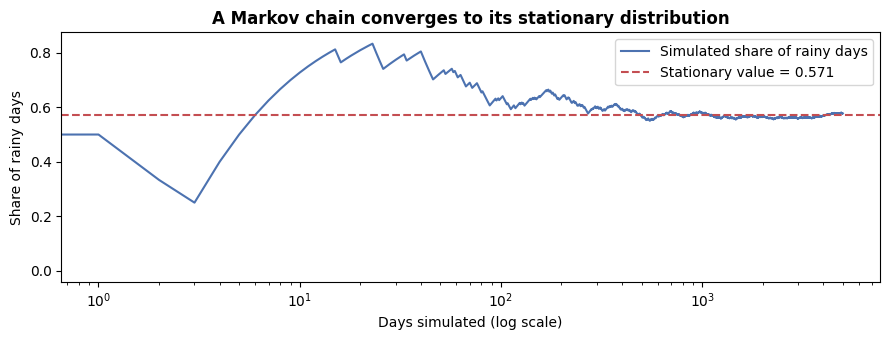

In [3]:
# Exact: left eigenvector of P with eigenvalue 1
eigvals, eigvecs = np.linalg.eig(P.T)
pi = np.real(eigvecs[:, np.isclose(eigvals, 1)].flatten())
pi = pi / pi.sum()
print(f"Exact stationary distribution:  Rainy = {pi[0]:.3f}, Sunny = {pi[1]:.3f}")

# Simulation: running share of rainy days over 5,000 days
long_run = simulate_chain('Sunny', 5000, P, states)
rainy_share = np.cumsum([s == 'Rainy' for s in long_run]) / np.arange(1, len(long_run) + 1)
print(f"Simulated share after 5,000 days: Rainy = {rainy_share[-1]:.3f}")

plt.figure(figsize=(9, 3.5))
plt.plot(rainy_share, color='#4C72B0', label='Simulated share of rainy days')
plt.axhline(pi[0], color='#C44E52', ls='--', label=f'Stationary value = {pi[0]:.3f}')
plt.xscale('log')
plt.xlabel('Days simulated (log scale)')
plt.ylabel('Share of rainy days')
plt.title('A Markov chain converges to its stationary distribution', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

Whichever state we start in, the chain ends up rainy **4/7 ≈ 57%** of the time. That long-run behavior is fully determined by the transition matrix.

---
## 2. Markov Models for Text: the Bigram Language Model

Treat **words as states** and we get a language model. A **bigram model** is a first-order Markov chain over words: the probability of the next word depends only on the current word.

$$P(w_i \mid w_{i-1}) = \frac{\text{count}(w_{i-1}, w_i)}{\text{count}(w_{i-1})}$$

We train one on Lewis Carroll's *Alice's Adventures in Wonderland* (from NLTK's Gutenberg corpus) and use it to generate new text.

In [4]:
from nltk.corpus import gutenberg

raw_text = gutenberg.raw('carroll-alice.txt')

def clean_sentence(sentence):
    # Keep words and contractions ("don't", "alice's"); drop punctuation and numbers
    words = re.findall(r"[a-z]+(?:'[a-z]+)?", sentence.lower())
    return ['<s>'] + words + ['</s>'] if words else None

sentences = [s for s in (clean_sentence(x) for x in nltk.sent_tokenize(raw_text)) if s]

# 90% of sentences for training, 10% held out for evaluation
random.shuffle(sentences)
split = int(0.9 * len(sentences))
train_sents, test_sents = sentences[:split], sentences[split:]

print(f"Sentences: {len(sentences)}  (train {len(train_sents)}, test {len(test_sents)})")
print("Example:", " ".join(train_sents[0]))

Sentences: 1625  (train 1462, test 163)
Example: <s> all the time they were playing the queen never left off quarrelling with the other players and shouting off with his head </s>


In [5]:
class BigramLM:
    """A bigram (first-order Markov) language model with optional add-k smoothing."""

    def __init__(self, sentences, k=0.0):
        self.k = k
        self.unigrams = Counter()
        self.bigrams = defaultdict(Counter)
        for sent in sentences:
            for prev, word in zip(sent, sent[1:]):
                self.unigrams[prev] += 1
                self.bigrams[prev][word] += 1
        self.vocab = set(w for s in sentences for w in s) | {'<unk>'}
        self.V = len(self.vocab)

    def prob(self, prev, word):
        """P(word | prev) with add-k smoothing (k=0 is the plain MLE)."""
        prev = prev if prev in self.vocab else '<unk>'
        word = word if word in self.vocab else '<unk>'
        count_pair = self.bigrams[prev][word]
        count_prev = self.unigrams[prev]
        denom = count_prev + self.k * self.V
        return (count_pair + self.k) / denom if denom > 0 else 0.0

    def next_word_distribution(self, prev, top_n=8):
        counts = self.bigrams[prev]
        total = sum(counts.values())
        return [(w, c / total) for w, c in counts.most_common(top_n)]

    def generate(self, max_words=20, seed=None):
        """Walk the Markov chain from <s>, sampling each next word from P(w | prev)."""
        rng = random.Random(seed)
        word, out = '<s>', []
        for _ in range(max_words):
            choices = self.bigrams[word]
            word = rng.choices(list(choices), weights=list(choices.values()))[0]
            if word == '</s>':
                break
            out.append(word)
        return " ".join(out)

lm = BigramLM(train_sents)
print(f"Vocabulary size: {lm.V:,}   Distinct bigrams: {sum(len(c) for c in lm.bigrams.values()):,}")

Vocabulary size: 2,483   Distinct bigrams: 13,226


### What comes after a word?

Each word has its own probability distribution over the next word. This is one row of a (very large) transition matrix.

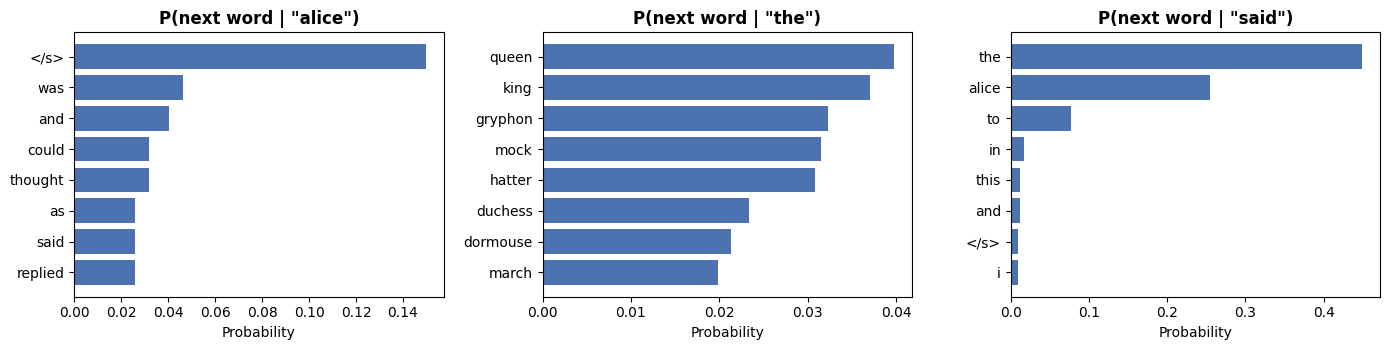

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, w in zip(axes, ['alice', 'the', 'said']):
    words, probs = zip(*lm.next_word_distribution(w))
    ax.barh(words[::-1], probs[::-1], color='#4C72B0')
    ax.set_title(f'P(next word | "{w}")', fontweight='bold')
    ax.set_xlabel('Probability')
plt.tight_layout()
plt.show()

In [7]:
print("Sentences generated by the bigram model:\n")
for seed in range(6):
    print(f"  {seed + 1}. {lm.generate(seed=seed)}")

Sentences generated by the bigram model:

  1. who is to herself in the cur such a right i'm glad to speak and the simple rules their arguments
  2. and book her eyes very important as you won't you a voice died away
  3. next and she was obliged to ask
  4. said alice shall be more than nine the queen's absence and they can't be like being broken to say creatures
  5. said the trees a very unpleasant things happening
  6. then they looked under its nest


The output is **locally fluent** (each word pair is plausible) but **globally incoherent**, because the model only ever looks one word back. That is the core limitation of low-order Markov models, and why NLP moved toward n-grams with longer context, RNNs and transformers.

---
## 3. Evaluating Language Models: Smoothing and Perplexity

### The zero-probability problem

A pure MLE model gives probability **0** to any word pair it never saw in training. One unseen bigram makes the probability of the whole sentence 0.

In [8]:
unseen = [(p, w) for s in test_sents for p, w in zip(s, s[1:]) if lm.bigrams[p][w] == 0]
total = sum(len(s) - 1 for s in test_sents)
print(f"Test bigrams never seen in training: {len(unseen):,} of {total:,} ({len(unseen) / total:.1%})")
print("Examples:", unseen[:5])
print(f"\nMLE probability of the bigram {unseen[0]}: {lm.prob(*unseen[0])}")

Test bigrams never seen in training: 1,254 of 3,095 (40.5%)
Examples: [("doesn't", 'look'), ('look', 'like'), ('like', 'one'), ('they', 'doing'), ('eaglet', '</s>')]

MLE probability of the bigram ("doesn't", 'look'): 0.0


### Laplace (add-k) smoothing

Smoothing moves a little probability mass from seen events to unseen ones. **Add-k smoothing** adds $k$ to every count:

$$P_{\text{add-}k}(w_i \mid w_{i-1}) = \frac{\text{count}(w_{i-1}, w_i) + k}{\text{count}(w_{i-1}) + k\,|V|}$$

With $k = 1$ this is **Laplace smoothing**.

### Perplexity

**Perplexity** measures how "surprised" a model is by unseen text. Lower is better. It's the inverse probability of the test set, normalized by the number of words:

$$\text{PP}(W) = \exp\left(-\frac{1}{N} \sum_{i=1}^{N} \ln P(w_i \mid w_{i-1})\right)$$

A perplexity of 100 means the model is, on average, as uncertain as if it were choosing uniformly among 100 words.

In [9]:
def perplexity(model, sentences):
    log_prob, n = 0.0, 0
    for sent in sentences:
        for prev, word in zip(sent, sent[1:]):
            p = model.prob(prev, word)
            if p == 0:
                return float('inf')
            log_prob += np.log(p)
            n += 1
    return float(np.exp(-log_prob / n))

results = []
for k in [0, 1.0, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001]:
    m = BigramLM(train_sents, k=k)
    results.append({'k': k,
                    'train_perplexity': perplexity(m, train_sents),
                    'test_perplexity': perplexity(m, test_sents)})

pp = pd.DataFrame(results)
pp['smoothing'] = pp['k'].map(lambda k: 'MLE (none)' if k == 0 else ('Laplace (add-1)' if k == 1 else f'add-{k}'))
pp[['smoothing', 'train_perplexity', 'test_perplexity']].round(1)

,smoothing,train_perplexity,test_perplexity
0,MLE (none),20.2,inf
1,Laplace (add-1),541.5,789.6
2,add-0.5,347.0,607.7
3,add-0.1,120.8,366.0
4,add-0.05,81.0,319.4
5,add-0.01,39.6,294.0
6,add-0.005,32.1,312.1
7,add-0.001,23.8,426.2


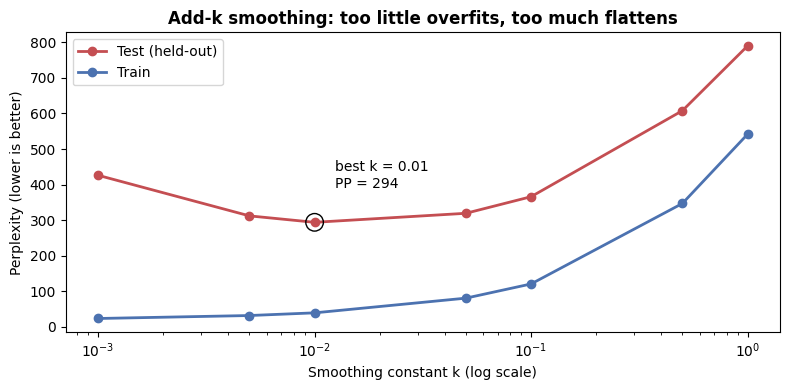

In [10]:
sm = pp[pp.k > 0].sort_values('k')
best = sm.loc[sm.test_perplexity.idxmin()]

plt.figure(figsize=(8, 4))
plt.plot(sm.k, sm.test_perplexity, 'o-', color='#C44E52', lw=2, label='Test (held-out)')
plt.plot(sm.k, sm.train_perplexity, 'o-', color='#4C72B0', lw=2, label='Train')
plt.scatter([best.k], [best.test_perplexity], s=160, facecolors='none', edgecolors='black', zorder=5)
plt.annotate(f"best k = {best.k}\nPP = {best.test_perplexity:.0f}", (best.k, best.test_perplexity),
             textcoords='offset points', xytext=(15, 25))
plt.xscale('log')
plt.xlabel('Smoothing constant k (log scale)')
plt.ylabel('Perplexity (lower is better)')
plt.title('Add-k smoothing: too little overfits, too much flattens', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

**Takeaways:**
- **Without smoothing**, test perplexity is **infinite**: a single unseen bigram gives the test set zero probability.
- **Laplace (add-1) is far too strong** for a large vocabulary. Adding 1 to every one of |V| possible next words steals most of the probability mass from the bigrams actually seen.
- A **small k** gives the best held-out perplexity. Smoothing is a bias-variance trade-off, so $k$ should be tuned on held-out data.

---
## 4. Text Classification with Naive Bayes

**Text classification** assigns predefined labels to documents: spam detection, topic labelling, sentiment analysis.

**Multinomial Naive Bayes** applies Bayes' rule with the "naive" assumption that words are independent given the class:

$$P(c \mid d) \propto P(c) \prod_{w \in d} P(w \mid c)$$

It's fast, needs little data, and is a strong baseline for text. It also uses **Laplace smoothing** internally (the `alpha` parameter), for the same zero-probability reason as in Section 3.

### Topic classification: 20 Newsgroups

About 11,000 posts across 20 discussion topics.

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset (for text classification)
newsgroups = fetch_20newsgroups(subset='train')

# Split the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(newsgroups.data, newsgroups.target, test_size=0.3, random_state=42)

# Vectorize the text using CountVectorizer (bag of words model)
vectorizer = CountVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train a Naive Bayes classifier (Multinomial Naive Bayes)
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_vec, y_train)

# Make predictions on the test set
y_pred = nb_classifier.predict(X_test_vec)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=newsgroups.target_names))

Accuracy: 0.8580
Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.93      0.97      0.95       135
           comp.graphics       0.60      0.88      0.72       166
 comp.os.ms-windows.misc       0.93      0.16      0.27       170
comp.sys.ibm.pc.hardware       0.62      0.84      0.71       182
   comp.sys.mac.hardware       0.90      0.78      0.84       183
          comp.windows.x       0.71      0.92      0.80       169
            misc.forsale       0.86      0.74      0.79       172
               rec.autos       0.92      0.89      0.91       191
         rec.motorcycles       0.93      0.92      0.93       198
      rec.sport.baseball       0.96      0.95      0.96       168
        rec.sport.hockey       0.95      0.97      0.96       163
               sci.crypt       0.91      0.93      0.92       195
         sci.electronics       0.85      0.79      0.82       177
                 sci.med       0.96

Naive Bayes reaches **86% accuracy across 20 topics** with nothing more than word counts.

The errors are concentrated in **overlapping topics**:
- **`comp.os.ms-windows.misc` has recall 0.16**: most of its posts are predicted as other computer topics, which is why `comp.graphics` (precision 0.60), `comp.sys.ibm.pc.hardware` (0.62) and `comp.windows.x` (0.71) have low precision. These groups share words like *windows*, *file*, *driver* and *dos*.
- **`talk.religion.misc` has recall 0.58**: it shares vocabulary with `alt.atheism` and `soc.religion.christian`.

Topics with distinctive vocabulary, such as hockey, baseball, medicine and space, score 0.94–0.96 F1.

---
## 5. Sentiment Classification: Count vs TF-IDF and Feature Selection

Now a binary task: is an IMDB movie review **positive or negative**? We compare:
1. **Feature engineering:** `CountVectorizer` vs `TfidfVectorizer`
2. **Feature selection:** keeping only the top-*k* words ranked by the **Chi-squared (χ²) test**

> **Why not Recursive Feature Elimination (RFE)?** RFE repeatedly retrains a model and drops the weakest features. With tens of thousands of sparse word features that means thousands of refits, which is impractically slow. Recent scikit-learn versions also don't expose per-feature weights for `MultinomialNB` that RFE needs. The χ² test scores every feature in a single pass, which is why it's the standard choice for text.

In [12]:
url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
imdb = pd.read_csv(url)

# Remove HTML line breaks (<br />), a common artifact in IMDB reviews
imdb['review'] = imdb['review'].str.replace(r'<br\s*/?>', ' ', regex=True)
imdb['label'] = (imdb['sentiment'] == 'positive').astype(int)

print(imdb.shape)
print(imdb['sentiment'].value_counts())

(50000, 3)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline

Xtr, Xte, ytr, yte = train_test_split(imdb['review'], imdb['label'], test_size=0.2,
                                      random_state=42, stratify=imdb['label'])

vectorizers = {
    'Count':  CountVectorizer(stop_words='english', min_df=5),
    'TF-IDF': TfidfVectorizer(stop_words='english', min_df=5),
}
k_values = [500, 1000, 5000, 10000, 'all']

rows = []
for vec_name, vec in vectorizers.items():
    Xtr_v = vec.fit_transform(Xtr)
    Xte_v = vec.transform(Xte)
    n_features = Xtr_v.shape[1]
    for k in k_values:
        selector = SelectKBest(chi2, k=k).fit(Xtr_v, ytr)
        clf = MultinomialNB().fit(selector.transform(Xtr_v), ytr)
        acc = accuracy_score(yte, clf.predict(selector.transform(Xte_v)))
        rows.append({'features': vec_name, 'k': n_features if k == 'all' else k, 'accuracy': acc})

comparison = pd.DataFrame(rows)
print(f"Vocabulary size (min_df=5): {n_features:,} words\n")
comparison.pivot(index='k', columns='features', values='accuracy').round(4)

Vocabulary size (min_df=5): 33,325 words



features,Count,TF-IDF
k,,
500,0.8499,0.8600
1000,0.8511,0.8635
5000,0.8561,0.8672
10000,0.8526,0.8655
33325,0.8552,0.8641


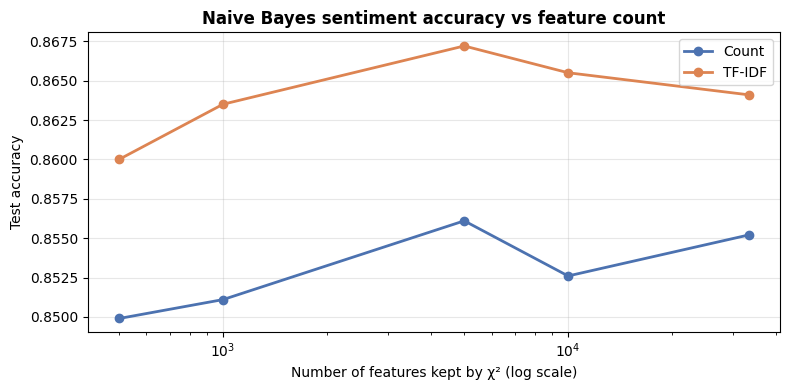

In [14]:
plt.figure(figsize=(8, 4))
for name, color in [('Count', '#4C72B0'), ('TF-IDF', '#DD8452')]:
    d = comparison[comparison.features == name]
    plt.plot(d.k, d.accuracy, 'o-', lw=2, color=color, label=name)
plt.xscale('log')
plt.xlabel('Number of features kept by χ² (log scale)')
plt.ylabel('Test accuracy')
plt.title('Naive Bayes sentiment accuracy vs feature count', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Findings:**
- **TF-IDF beats raw counts at every feature budget** (about +1 point). Down-weighting words that appear in every review helps even a simple Naive Bayes model.
- **More features isn't always better.** Keeping only the **5,000 most informative words** (15% of the vocabulary) slightly *outperforms* using all 33K. The discarded words mostly added noise.
- Even **500 χ²-selected words** reach about 86%, which shows how concentrated sentiment information is in a small set of words.

### Final model: inspecting what it learned

Best setup: TF-IDF features, k = 5,000, accuracy = 0.8672


              precision    recall  f1-score   support

    negative       0.86      0.87      0.87      5000
    positive       0.87      0.86      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



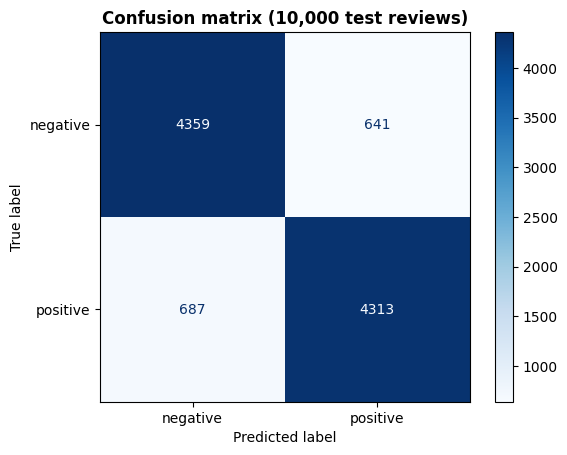

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_row = comparison.loc[comparison.accuracy.idxmax()]
best_k = int(best_row.k) if best_row.k < n_features else 'all'
print(f"Best setup: {best_row.features} features, k = {best_row.k:,}, accuracy = {best_row.accuracy:.4f}")

final = Pipeline([
    ('vec', vectorizers[best_row.features].__class__(stop_words='english', min_df=5)),
    ('chi2', SelectKBest(chi2, k=best_k)),
    ('nb', MultinomialNB()),
]).fit(Xtr, ytr)

pred = final.predict(Xte)
print(classification_report(yte, pred, target_names=['negative', 'positive']))

ConfusionMatrixDisplay(confusion_matrix(yte, pred), display_labels=['negative', 'positive']).plot(cmap='Blues', values_format='d')
plt.title('Confusion matrix (10,000 test reviews)', fontweight='bold')
plt.show()

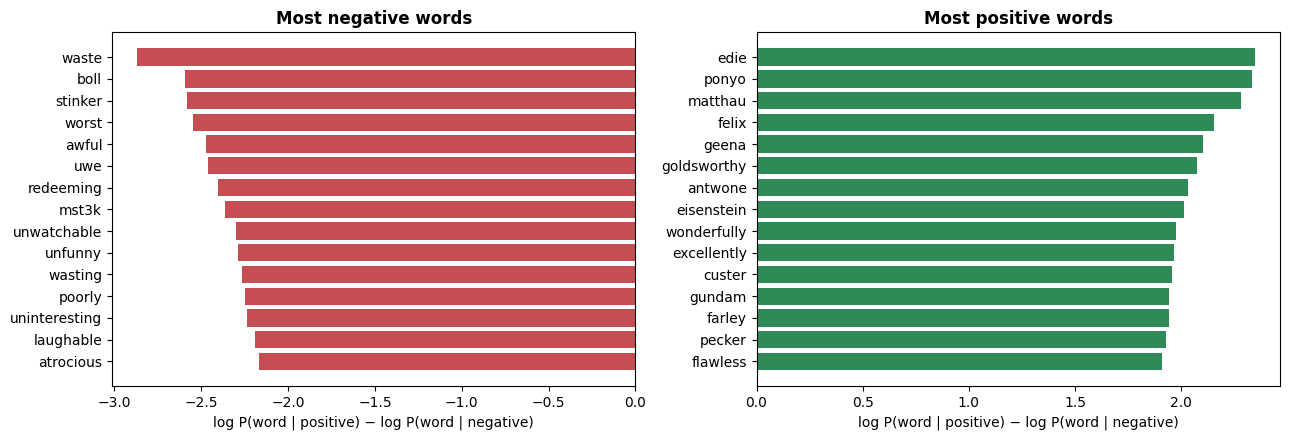

In [16]:
# Most informative words: largest difference in log P(word | class) between the two classes
vec, sel, nb = final.named_steps['vec'], final.named_steps['chi2'], final.named_steps['nb']
words = vec.get_feature_names_out()[sel.get_support()]
log_ratio = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]

top_pos = pd.Series(log_ratio, index=words).nlargest(15)
top_neg = pd.Series(log_ratio, index=words).nsmallest(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(top_neg.index[::-1], top_neg.values[::-1], color='#C44E52')
axes[0].set_title('Most negative words', fontweight='bold')
axes[1].barh(top_pos.index[::-1], top_pos.values[::-1], color='#2E8B57')
axes[1].set_title('Most positive words', fontweight='bold')
for ax in axes:
    ax.set_xlabel('log P(word | positive) − log P(word | negative)')
plt.tight_layout()
plt.show()

The negative side reads like a sentiment dictionary: *waste*, *worst*, *awful*, *unwatchable*, *atrocious*. It also picks up *boll* and *uwe* (director Uwe Boll, famous for poorly reviewed films) and *mst3k* (*Mystery Science Theater 3000*, a show that mocks bad movies).

The positive side is dominated by **names** (*edie*, *ponyo*, *matthau*, *felix*, *geena*): actors, characters and films that only ever appear in glowing reviews. These are real signals in this dataset, but they're also a warning. The model is partly memorizing *which movies people liked* rather than *how people express liking*, which won't transfer to reviews of new films.

In [17]:
new_reviews = [
    "An absolute masterpiece. The acting was superb and the story moved me to tears.",
    "A complete waste of two hours. The plot was predictable and the dialogue was awful.",
    "It was okay. Some good moments, but overall pretty forgettable.",
    "I expected it to be terrible, but it turned out to be surprisingly brilliant.",
]
for text, p in zip(new_reviews, final.predict_proba(new_reviews)[:, 1]):
    label = 'POSITIVE' if p >= 0.5 else 'NEGATIVE'
    print(f"{label:<9} (P(pos) = {p:.2f})  {text}")

POSITIVE  (P(pos) = 0.88)  An absolute masterpiece. The acting was superb and the story moved me to tears.
NEGATIVE  (P(pos) = 0.04)  A complete waste of two hours. The plot was predictable and the dialogue was awful.
NEGATIVE  (P(pos) = 0.21)  It was okay. Some good moments, but overall pretty forgettable.
NEGATIVE  (P(pos) = 0.49)  I expected it to be terrible, but it turned out to be surprisingly brilliant.


The last review shows Naive Bayes' blind spot. *"I expected it to be **terrible**, but it turned out to be surprisingly **brilliant**"* is clearly positive, but the model is a coin flip (P = 0.49): it adds up "terrible" and "brilliant" as independent clues and can't see that "but" reverses the sentiment. Capturing that needs a model of **word order and context**.

---
## Summary

| Topic | Key idea | Result in this notebook |
|-------|----------|-------------------------|
| Markov chains | Next state depends only on the current state | The weather chain converges to 57% rainy days |
| Bigram language model | A Markov chain over words | Generates locally fluent but incoherent text |
| Smoothing | Give unseen events non-zero probability | MLE perplexity is infinite; a small add-k works best |
| Perplexity | Lower = less surprised by unseen text | Used to tune the smoothing constant k |
| Naive Bayes | Bayes' rule + word independence | 86% accuracy on 20 topics |
| Feature selection | Keep the most class-informative words (χ²) | TF-IDF + top 5,000 χ² words: 86.7% on IMDB, beating all 33K features |

**Limitations to remember:**
- Bigram models only see one word of context, and Naive Bayes ignores word order entirely, so "not good" is just "not" + "good".
- Both rely on counts, so they can't relate synonyms like "film" and "movie".

These limitations motivate the next topics: **word embeddings**, **RNNs/LSTMs** and **transformers**.